Importin libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

**loading data**

In [ ]:
df=pd.read_csv('/content/ParisHousing-selected-columns (1).csv')

In [ ]:
# top row of data
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,3,8,0,1,4313,956,0,7,7559081.5
1,80771,39,1,1,98,8,6,1,0,3653,128,1,2,8085989.5
2,55712,58,0,1,19,6,8,0,0,2937,135,1,9,5574642.1
3,32316,47,0,0,6,10,4,0,1,659,359,0,3,3232561.2
4,70429,19,1,1,90,3,7,1,0,8435,292,1,4,7055052.0


In [ ]:
# shape of data (row's and columns)
df.shape

(10000, 14)

## EDA

In [ ]:
# name of columns
df.columns

Index(['squareMeters', 'numberOfRooms', 'hasYard', 'hasPool', 'floors',
       'cityPartRange', 'numPrevOwners', 'isNewBuilt', 'hasStormProtector',
       'basement', 'garage', 'hasStorageRoom', 'hasGuestRoom', 'price'],
      dtype='object')

In [ ]:
# understanding the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityPartRange      10000 non-null  int64  
 6   numPrevOwners      10000 non-null  int64  
 7   isNewBuilt         10000 non-null  int64  
 8   hasStormProtector  10000 non-null  int64  
 9   basement           10000 non-null  int64  
 10  garage             10000 non-null  int64  
 11  hasStorageRoom     10000 non-null  int64  
 12  hasGuestRoom       10000 non-null  int64  
 13  price              10000 non-null  float64
dtypes: float64(1), int64(13)
memory usage: 1.1 MB


In [ ]:
# missing value analysis
df.isnull().sum()

,0
squareMeters,0
numberOfRooms,0
hasYard,0
hasPool,0
floors,0
cityPartRange,0
numPrevOwners,0
isNewBuilt,0
hasStormProtector,0
basement,0


no missing value

In [ ]:
#duplicate analysis
df.duplicated().sum()

np.int64(0)

no duplicated value

In [ ]:
# discriptive statistics
df.describe()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,garage,hasStorageRoom,hasGuestRoom,price
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,1.000000e+04
mean,49870.13120,50.358400,0.508700,0.496800,50.276300,5.510100,5.521700,0.499100,0.499900,5033.103900,553.12120,0.503000,4.99460,4.993448e+06
std,28774.37535,28.816696,0.499949,0.500015,28.889171,2.872024,2.856667,0.500024,0.500025,2876.729545,262.05017,0.500016,3.17641,2.877424e+06
min,89.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,100.00000,0.000000,0.00000,1.031350e+04
25%,25098.50000,25.000000,0.000000,0.000000,25.000000,3.000000,3.000000,0.000000,0.000000,2559.750000,327.75000,0.000000,2.00000,2.516402e+06
50%,50105.50000,50.000000,1.000000,0.000000,50.000000,5.000000,5.000000,0.000000,0.000000,5092.500000,554.00000,1.000000,5.00000,5.016180e+06
75%,74609.75000,75.000000,1.000000,1.000000,76.000000,8.000000,8.000000,1.000000,1.000000,7511.250000,777.25000,1.000000,8.00000,7.469092e+06
max,99999.00000,100.000000,1.000000,1.000000,100.000000,10.000000,10.000000,1.000000,1.000000,10000.000000,1000.00000,1.000000,10.00000,1.000677e+07


Separating numerical and binary features

In [ ]:
binary_features = [
    "hasYard",
    "hasPool",
    "isNewBuilt",
    "hasStormProtector",
    "hasStorageRoom"
]

target = "price"

binary_data = df[binary_features]

numerical_features = [
    col for col in df.columns
    if col not in binary_features + [target]
]

numerical_data = df[numerical_features]

# EDA for univriate

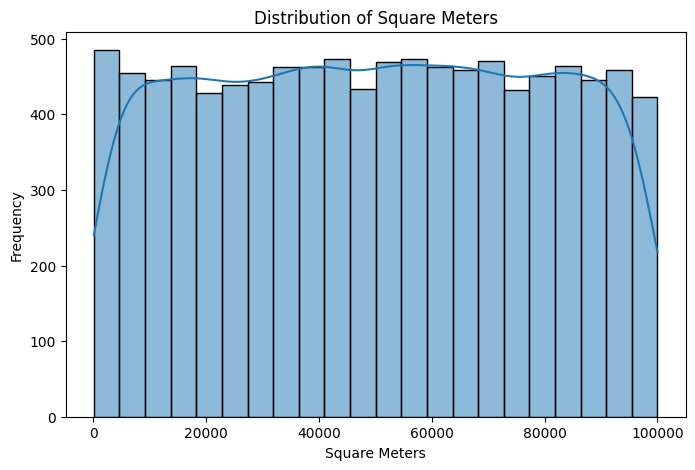

In [ ]:
# dist of area
plt.figure(figsize=(8,5))

sns.histplot(df["squareMeters"], kde=True)

plt.title("Distribution of Square Meters")
plt.xlabel("Square Meters")
plt.ylabel("Frequency")

plt.show()

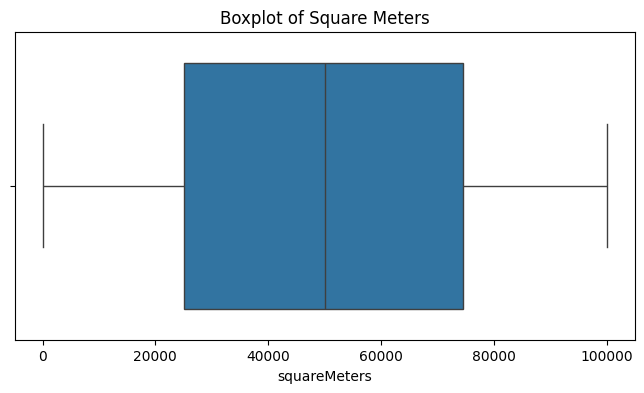

In [ ]:
# boxplot
plt.figure(figsize=(8,4))

sns.boxplot(x=df["squareMeters"])

plt.title("Boxplot of Square Meters")
plt.show()

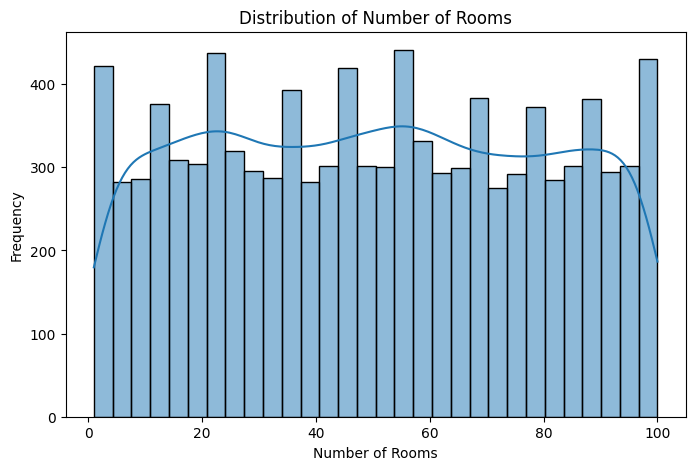

In [ ]:
# dist of room no
plt.figure(figsize=(8,5))

sns.histplot(df["numberOfRooms"], bins=30, kde=True)

plt.title("Distribution of Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_1831/4219772013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='cityPartRange',palette='Set2')


<Axes: xlabel='cityPartRange', ylabel='count'>

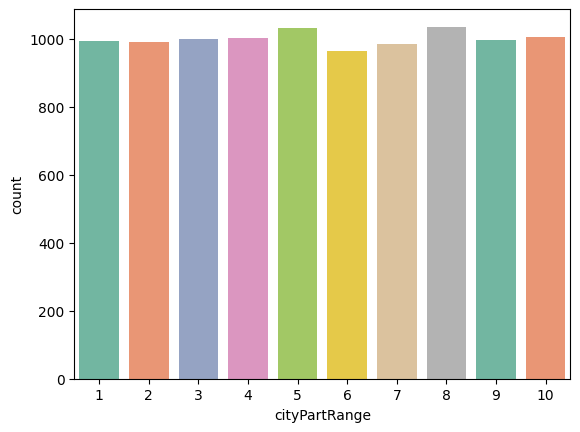

In [ ]:
# dist of city part range(0=cheapest ,10=most expensive)
sns.countplot(data=df,x='cityPartRange',palette='Set2')

/tmp/ipykernel_1831/432160188.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='hasGuestRoom',palette='Set1')


<Axes: xlabel='hasGuestRoom', ylabel='count'>

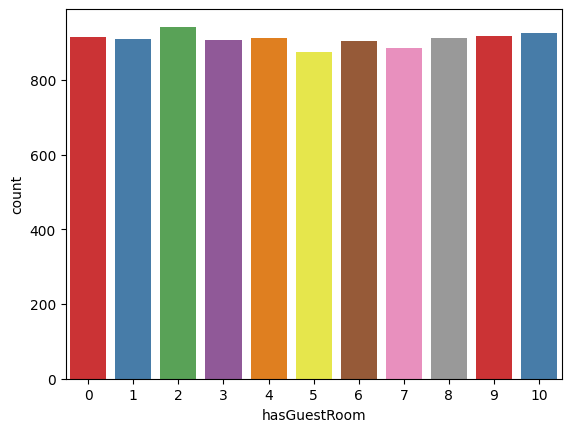

In [ ]:
sns.countplot(data=df,x='hasGuestRoom',palette='Set1')

# EDA for binary columns

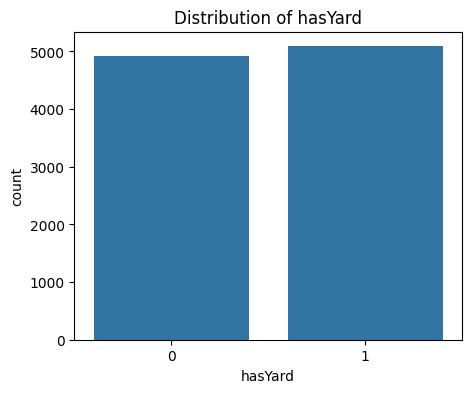

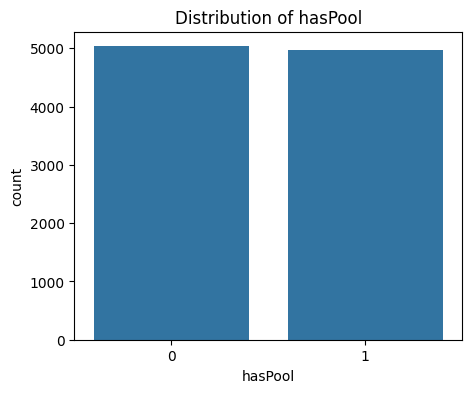

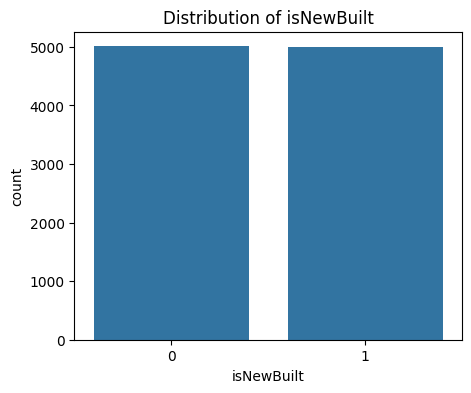

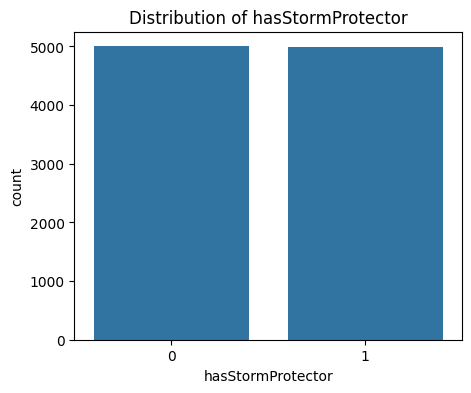

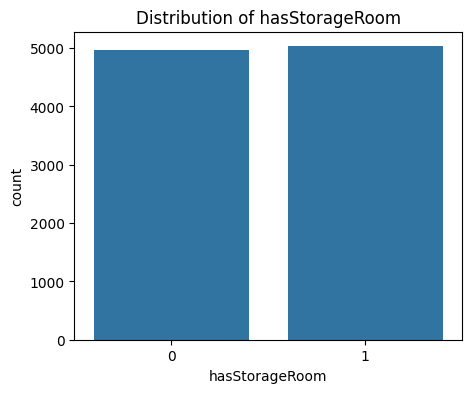

In [ ]:

for col in binary_features:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

Target variable

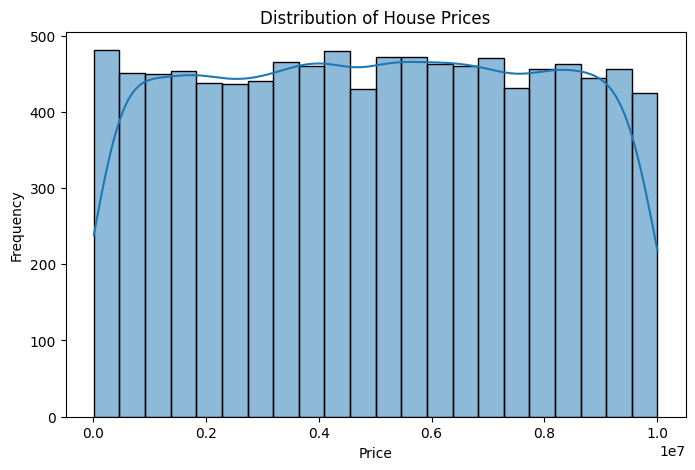

In [ ]:
# dist of house price
plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# skewness
df["price"].skew()

np.float64(-0.006449159112355322)

slightly negative skewed

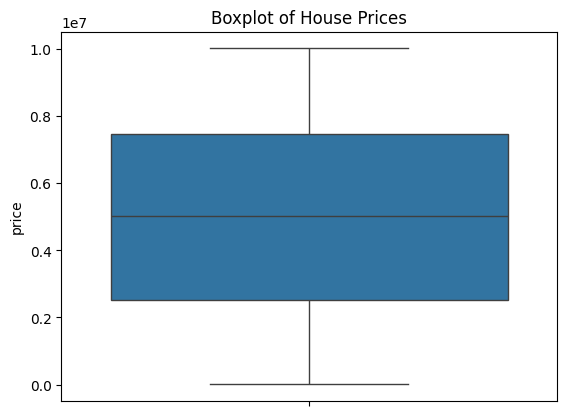

In [ ]:
# boxplot
sns.boxplot(y=df["price"])

plt.title("Boxplot of House Prices")
plt.show()

# Bivariate EDA

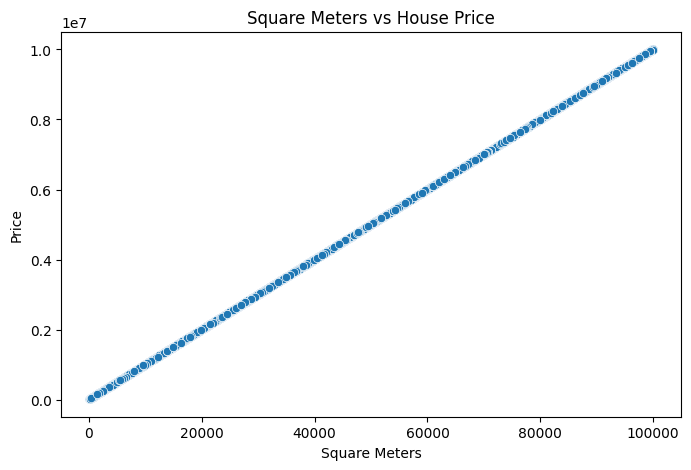

In [ ]:
# area vs price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="squareMeters",
    y="price"
)

plt.title("Square Meters vs House Price")
plt.xlabel("Square Meters")
plt.ylabel("Price")

plt.show()

the correlation is unusualy high r=0.99999

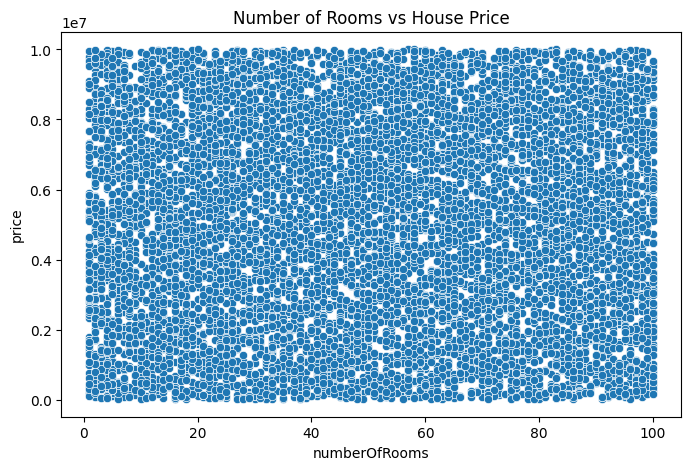

In [ ]:
# number of rooms vs price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="numberOfRooms",
    y="price"
)

plt.title("Number of Rooms vs House Price")
plt.show()

the relationship is very weak

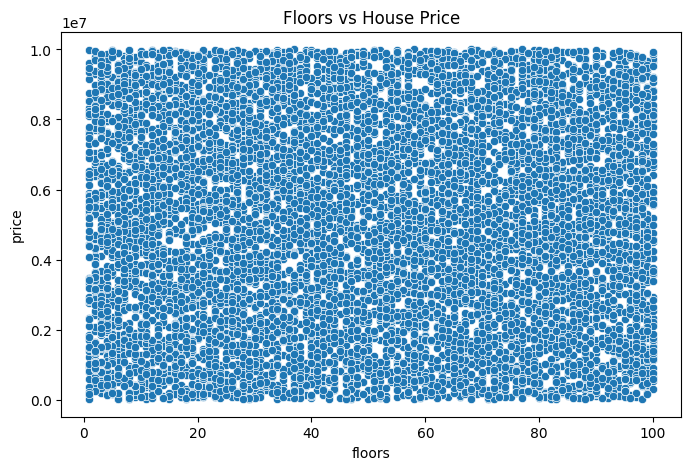

In [ ]:
# floors vs price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="floors",
    y="price"
)

plt.title("Floors vs House Price")
plt.show()

The relation is very weak

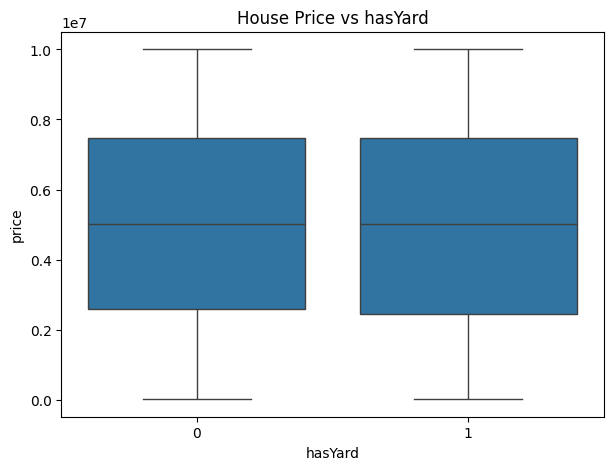

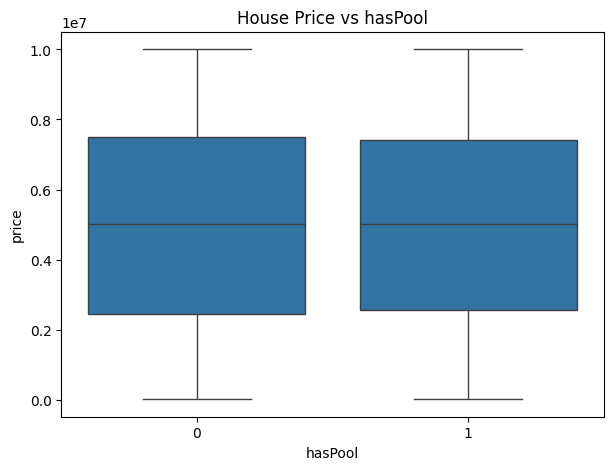

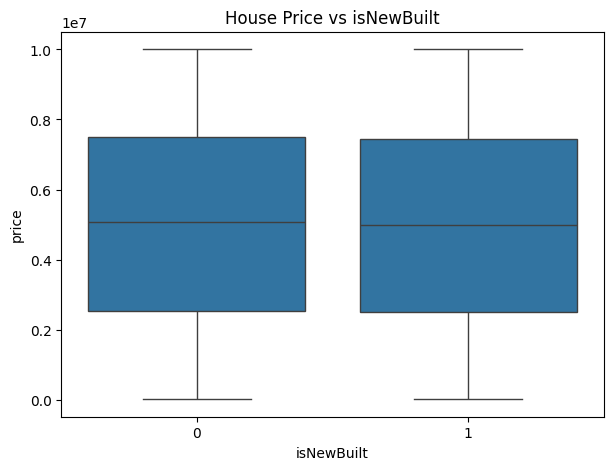

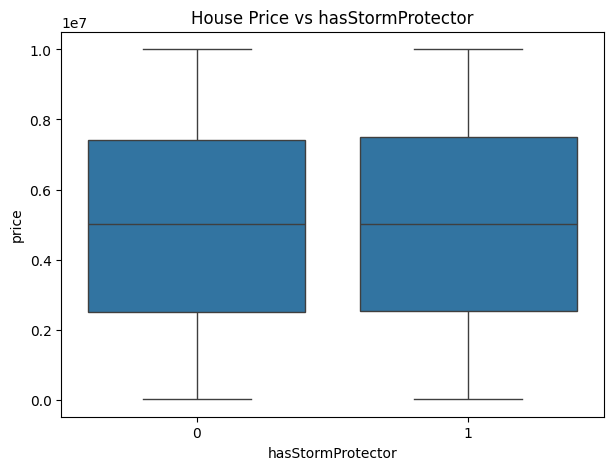

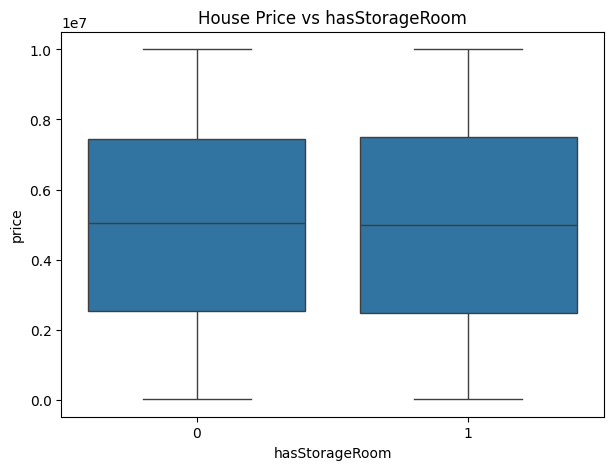

In [ ]:
# Binary feature vs price
for col in binary_features:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x=col, y="price")
    plt.title(f"House Price vs {col}")
    plt.show()

## Correlation analysis

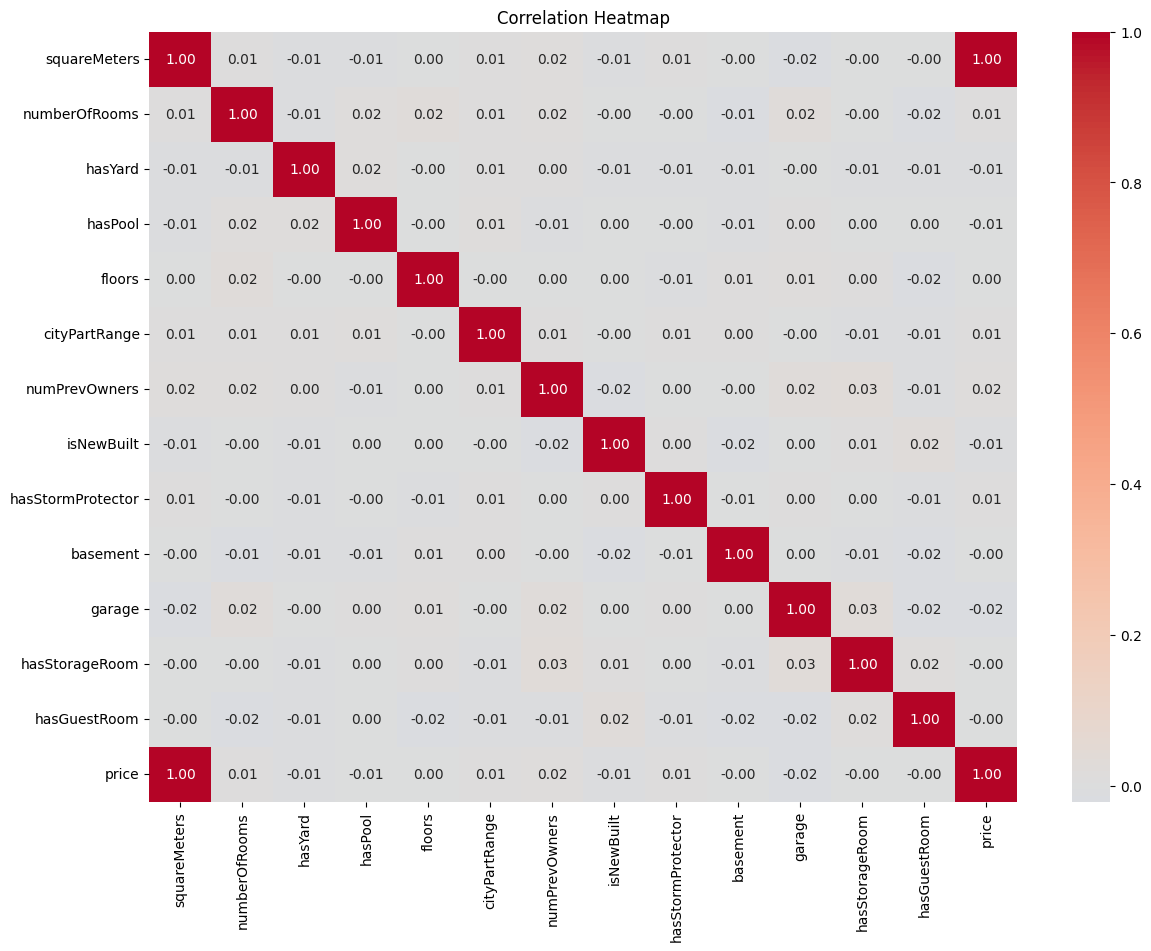

In [ ]:
# heatmap
plt.figure(figsize=(14,10))
correlation = df.corr(numeric_only=True)
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print(

    correlation["price"]

    .sort_values(ascending=False)

)

price                1.000000
squareMeters         0.999999
numPrevOwners        0.016619
numberOfRooms        0.009591
cityPartRange        0.008813
hasStormProtector    0.007496
floors               0.001654
hasGuestRoom        -0.000644
hasStorageRoom      -0.003485
basement            -0.003967
hasPool             -0.005070
hasYard             -0.006119
isNewBuilt          -0.010643
garage              -0.017229
Name: price, dtype: float64


# separating and scaling

In [ ]:
# Separate features and target

X = df.drop('price', axis=1)
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 13)
y shape: (10000,)


In [ ]:
# spliting
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (8000, 13)
X_test: (2000, 13)
y_train: (8000,)
y_test: (2000,)


In [ ]:
#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
#converting into dataframe
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,garage,hasStorageRoom,hasGuestRoom
9254,1.118998,0.222798,-1.014607,1.006521,-1.664664,0.514282,-1.578452,-0.994764,-0.998501,0.399467,0.706920,1.00025,-0.939629
1561,1.020945,1.298720,-1.014607,-0.993521,0.996310,0.514282,0.169170,1.005264,1.001501,0.302882,0.729793,-0.99975,-0.623482
1670,0.995487,0.708699,0.985604,1.006521,1.583798,1.557275,1.567268,1.005264,1.001501,-0.179002,-0.844610,1.00025,0.324960
6087,-1.185374,-0.887831,0.985604,-0.993521,0.166916,-1.571703,0.518694,-0.994764,1.001501,1.149219,1.175810,1.00025,0.957254
6669,-1.624404,0.292213,-1.014607,-0.993521,1.549240,0.166618,0.169170,1.005264,1.001501,1.621375,-0.810301,-0.99975,0.008813


# OLS mathod

In [ ]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train_scaled)

ols_model = sm.OLS(y_train, X_train_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.400e+09
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:24:50   Log-Likelihood:                -71712.
No. Observations:                8000   AIC:                         1.435e+05
Df Residuals:                    7986   BIC:                         1.436e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4.964e+06     21.16

influential point

In [ ]:
influence = ols_model.get_influence()

cooks_distance = influence.cooks_distance[0]

print(cooks_distance)

[6.50616060e-05 9.06318800e-07 6.59888807e-04 ... 5.58837030e-05
 4.78001399e-04 1.24497500e-05]


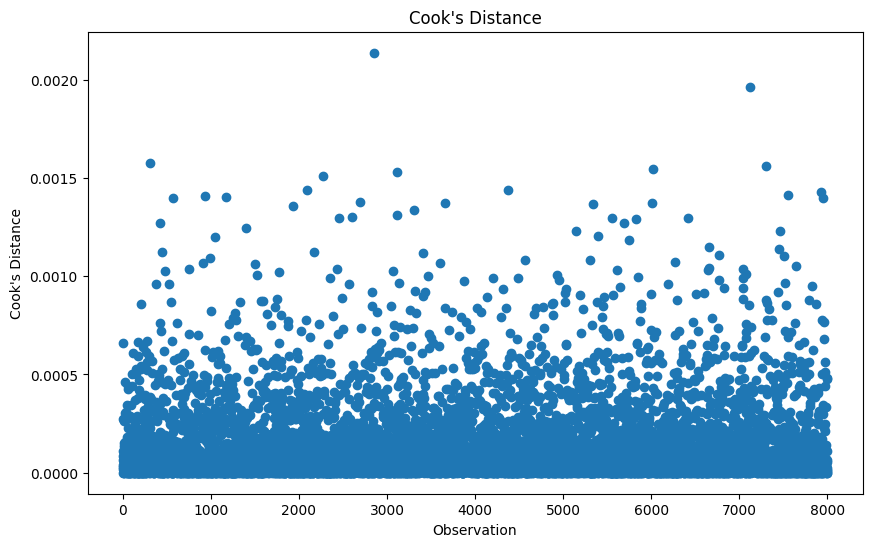

In [ ]:
#plot
plt.figure(figsize=(10, 6))

plt.scatter(
    range(len(cooks_distance)),
    cooks_distance
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")

plt.show()

# MLR

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

In [ ]:
# evaluat MLR
train_mae = mean_absolute_error(y_train, y_train_pred)

train_mse = mean_squared_error(y_train, y_train_pred)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)

test_mse = mean_squared_error(y_test, y_test_pred)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(y_test, y_test_pred)

print("Training Performance")

print("--------------------")

print("MAE :", train_mae)

print("MSE :", train_mse)

print("RMSE:", train_rmse)

print("R²  :", train_r2)

print("\nTesting Performance")

print("-------------------")

print("MAE :", test_mae)

print("MSE :", test_mse)

print("RMSE:", test_rmse)

print("R²  :", test_r2)

Training Performance
--------------------
MAE : 1470.582710199833
MSE : 3577579.1701591164
RMSE: 1891.4489604953967
R²  : 0.9999995612716578

Testing Performance
-------------------
MAE : 1508.8593954902801
MSE : 3691993.3820952903
RMSE: 1921.4560578101416
R²  : 0.9999995784797104


In [ ]:
# adjusted r2
n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Test R²:", test_r2)

print("Adjusted R²:", adjusted_r2)

Test R²: 0.9999995784797104
Adjusted R²: 0.9999995757205142


# Regration assumption

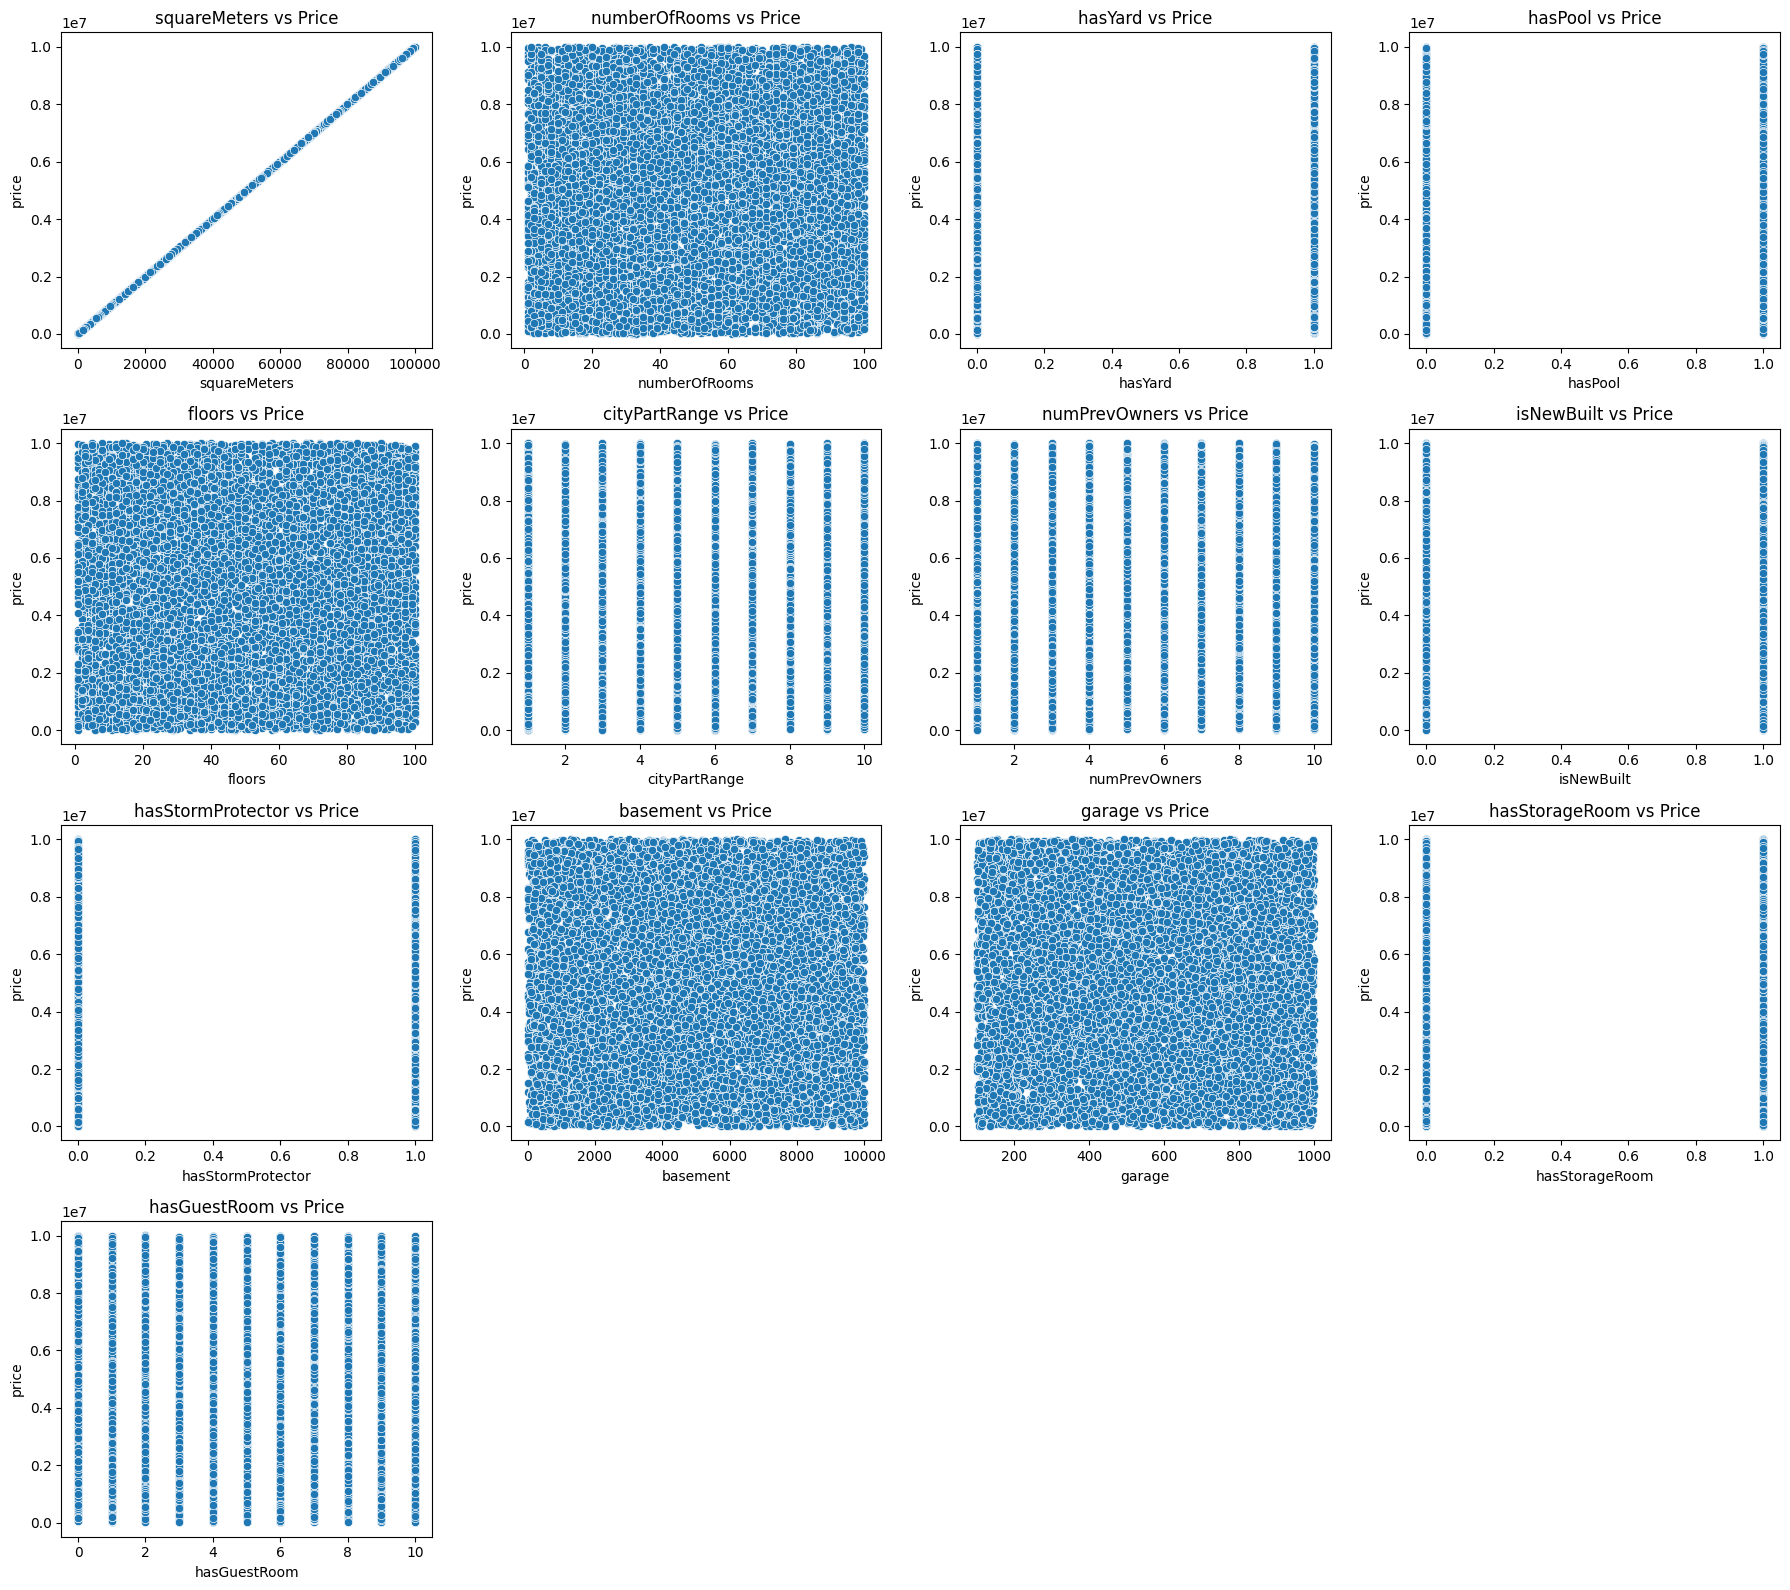

In [ ]:
# liniarity
features = X.columns

fig, axes = plt.subplots(
    4, 4,
    figsize=(18, 16)
)

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        data=df,
        x=feature,
        y='price',
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} vs Price')

for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

liniarity exist somewhat

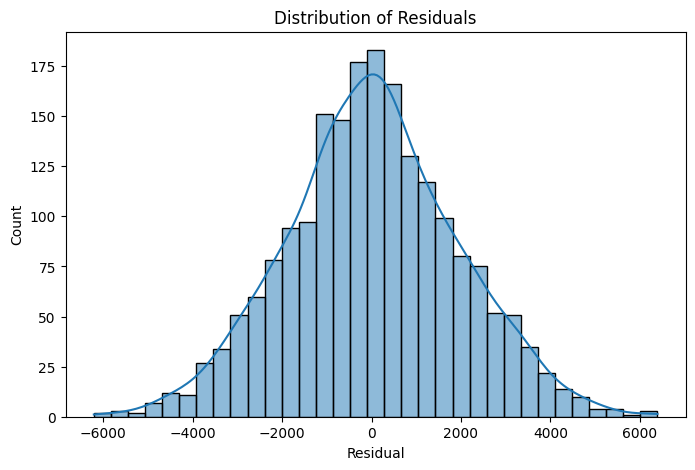

In [ ]:
# normality (residual analysis)
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

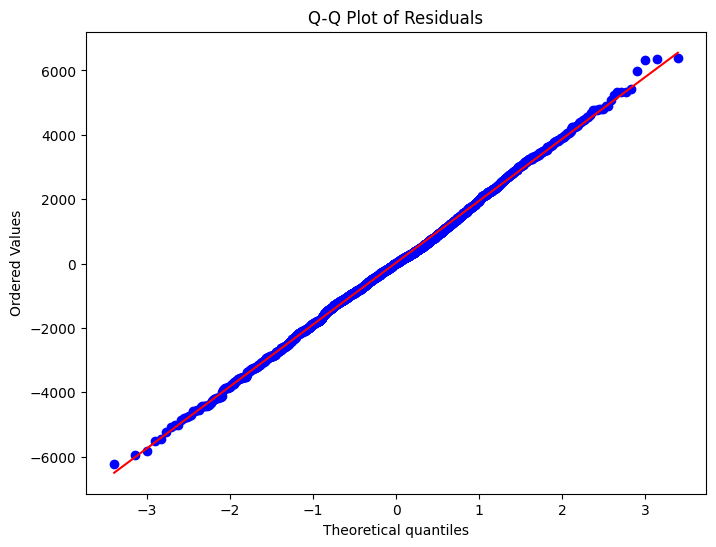

In [ ]:
# Q-Q plot
import scipy.stats as stats

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.show()

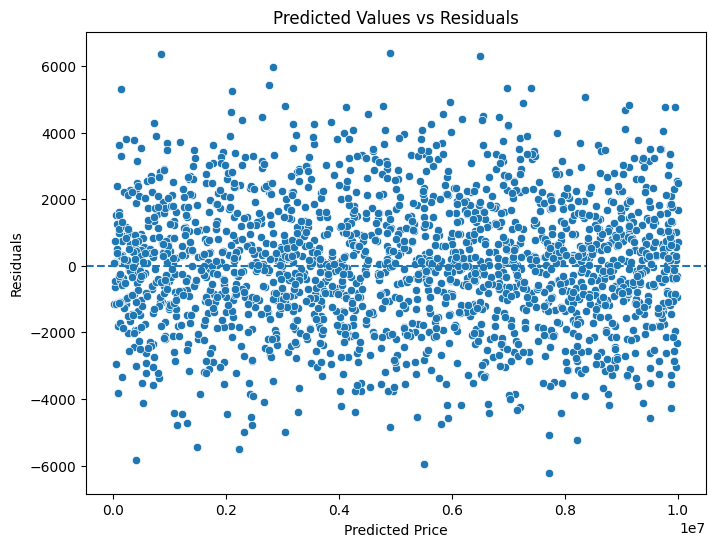

In [ ]:
# Homoscedasticity
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Predicted Values vs Residuals")

plt.show()

As from the above figure we can that we cant find any pattern of data between the residuals and Y_test_pred , therefore it is homoscedastic

In [ ]:
# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_train_scaled.values,
        i
    )
    for i in range(X_train_scaled.shape[1])
]

vif.sort_values(
    by="VIF",
    ascending=False
)

,Feature,VIF
11,hasStorageRoom,1.002740
10,garage,1.002637
12,hasGuestRoom,1.002388
6,numPrevOwners,1.002253
1,numberOfRooms,1.002016
4,floors,1.001616
5,cityPartRange,1.001470
7,isNewBuilt,1.001390
2,hasYard,1.001233
0,squareMeters,1.001216


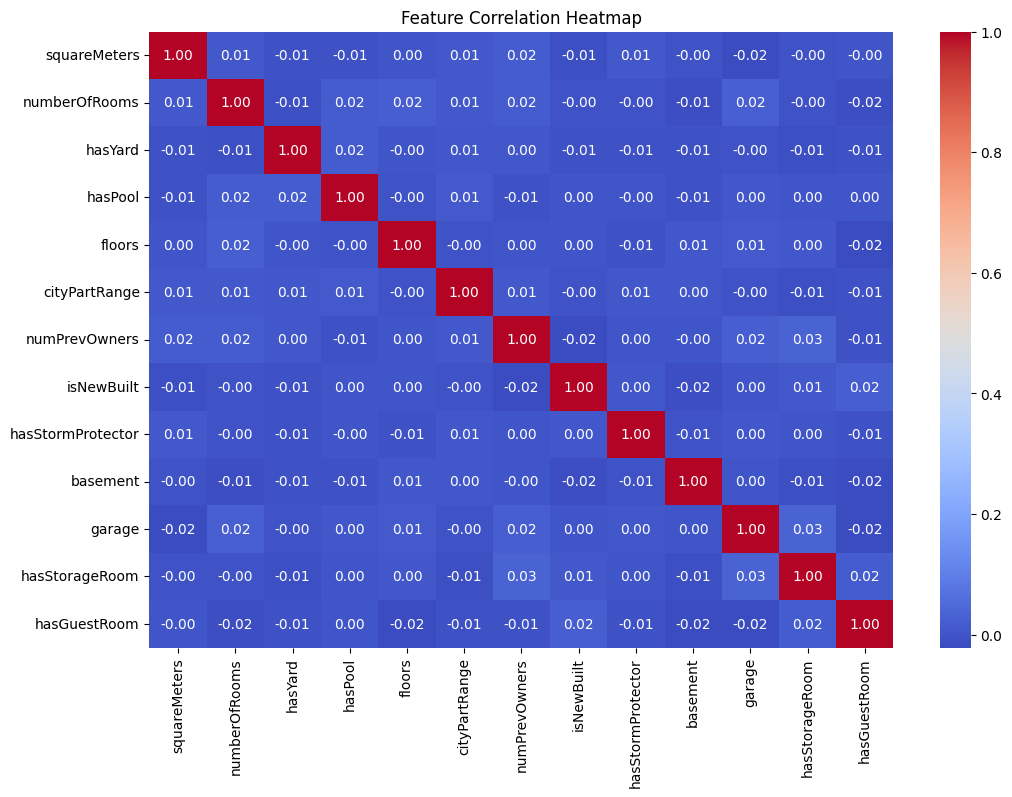

In [ ]:
# correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Applying other model

In [ ]:
models = {

    "Linear Regression": LinearRegression(),



    "Ridge": Ridge(),



    "Lasso": Lasso(),



    "Decision Tree": DecisionTreeRegressor(

        random_state=42

    ),



    "Random Forest": RandomForestRegressor(

        random_state=42,

        n_jobs=-1

    ),







}

In [ ]:
# model evaluation function
def evaluate_model(true, predicted, n, p):

    mae = mean_absolute_error(true, predicted)

    mse = mean_squared_error(true, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(true, predicted)

    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1) / (n - p - 1)
    )

    return mae, mse, rmse, r2, adjusted_r2

In [ ]:
# Train and compare all the model
model_results = []

for name, model in models.items():

    # Linear models use scaled data
    if name in ["Linear Regression", "Ridge", "Lasso"]:

        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

    # Tree models do not require scaling
    else:

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    # Training metrics
    train_mae, train_mse, train_rmse, train_r2, train_adj_r2 = \
        evaluate_model(
            y_train,
            y_train_pred,
            X_train.shape[0],
            X_train.shape[1]
        )

    # Testing metrics
    test_mae, test_mse, test_rmse, test_r2, test_adj_r2 = \
        evaluate_model(
            y_test,
            y_test_pred,
            X_test.shape[0],
            X_test.shape[1]
        )

    model_results.append([
        name,
        train_mae,
        train_rmse,
        train_r2,
        test_mae,
        test_rmse,
        test_r2,
        test_adj_r2
    ])

In [ ]:
# comparison table
results_df = pd.DataFrame(
    model_results,
    columns=[
        "Model",
        "Train MAE",
        "Train RMSE",
        "Train R2",
        "Test MAE",
        "Test RMSE",
        "Test R2",
        "Test Adjusted R2"
    ]
)

results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2,Test Adjusted R2
2,Lasso,1470.567242,1891.452460,1.0,1508.818748,1921.430629,1.000000,1.000000
0,Linear Regression,1470.582710,1891.448960,1.0,1508.859395,1921.456058,1.000000,1.000000
1,Ridge,1503.925761,1924.868630,1.0,1540.684936,1955.246160,1.000000,1.000000
4,Random Forest,1132.776716,1426.896748,1.0,3133.012045,3940.458108,0.999998,0.999998
3,Decision Tree,0.000000,0.000000,1.0,4306.372750,5446.096703,0.999997,0.999997


In [ ]:
# cross validation
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    if name in ["Linear Regression", "Ridge", "Lasso"]:
        X_cv = X_train_scaled
    else:
        X_cv = X_train

    scores = cross_val_score(
        model,
        X_cv,
        y_train,
        cv=5,
        scoring='r2'
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean CV R2",
        "Std CV R2"
    ]
)

cv_df.sort_values(
    by="Mean CV R2",
    ascending=False
)

,Model,Mean CV R2,Std CV R2
2,Lasso,1.000000,1.022449e-08
0,Linear Regression,1.000000,1.022035e-08
1,Ridge,1.000000,1.132196e-08
4,Random Forest,0.999998,1.720923e-08
3,Decision Tree,0.999996,1.090867e-07
